 # proyecto de series de tiempo alternativo
 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
from pickle import dump
import os

In [3]:
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv")

In [4]:
total_data["date"] = pd.to_datetime(total_data.date)
total_data = total_data.set_index("date")
ts_total = total_data["sales"]

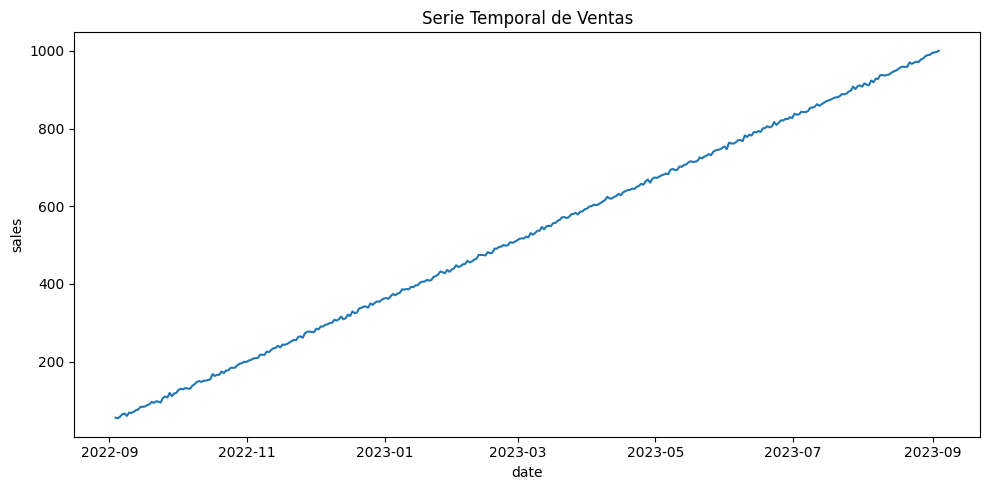

In [5]:
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = ts_total)
plt.title("Serie Temporal de Ventas")
plt.tight_layout()
plt.show()

In [7]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

print(test_stationarity(ts_total))

Resultados de la prueba de Dickey-Fuller:
Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64


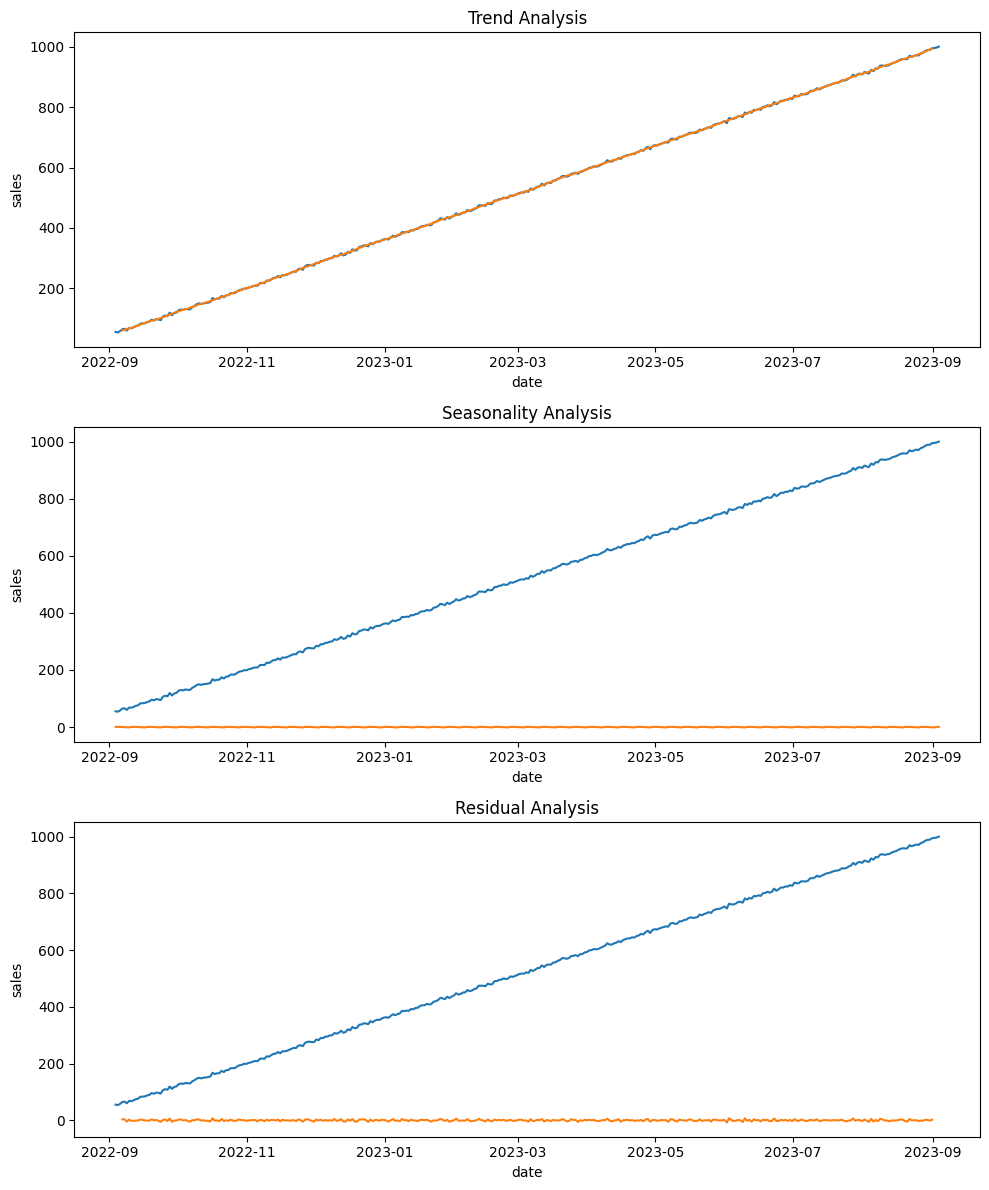

In [11]:
fig, axis = plt.subplots(3, 1, figsize = (10, 12))

 
sns.lineplot(ax = axis[0], data = ts_total)
sns.lineplot(ax = axis[0], data = trend)
axis[0].set_title("Trend Analysis")

 
sns.lineplot(ax = axis[1], data = ts_total)
sns.lineplot(ax = axis[1], data = seasonal)
axis[1].set_title("Seasonality Analysis")

 
sns.lineplot(ax = axis[2], data = ts_total)
sns.lineplot(ax = axis[2], data = residual)
axis[2].set_title("Residual Analysis")

plt.tight_layout()
plt.show()

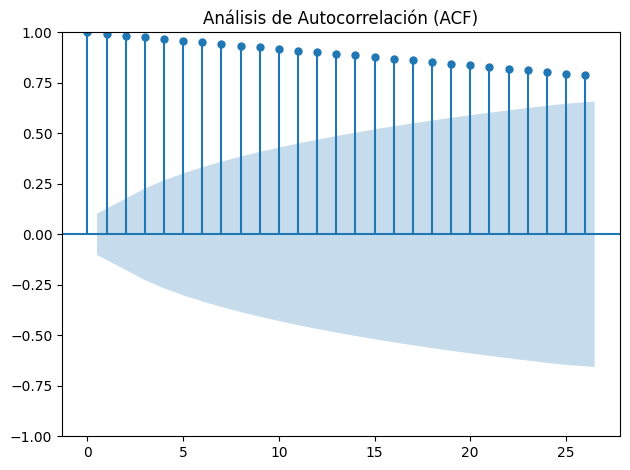

In [12]:
plot_acf(ts_total)
plt.title("Análisis de Autocorrelación (ACF)")
plt.tight_layout()
plt.show()

In [13]:
model = auto_arima(ts_total, seasonal = False, trace = True, m = 1) 
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.162, Time=2.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=0.45 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=0.71 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=0.20 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.39 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 4.578 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  366
M

In [14]:
forecast = model.predict(60)

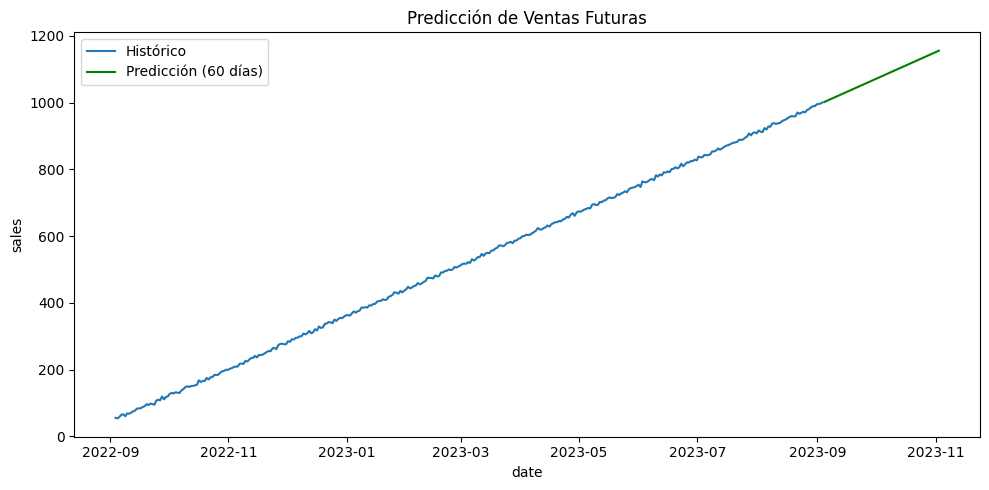

In [15]:
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = ts_total, label="Histórico")
sns.lineplot(data = forecast, color = "green", label="Predicción (60 días)")
plt.title("Predicción de Ventas Futuras")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
if not os.path.exists("../models"):
    os.makedirs("../models")

dump(model, open("../models/arima_model_sales.sav", "wb"))
